#Progetto analisi disastri aerei dal 1919 al 2023

### Caricamento librerie e dataframe

In [145]:
!pip install pycountry
import pandas as pd
import numpy as np
import plotly.express as px
import pycountry
import matplotlib.pyplot as plt

In [152]:
# URL del file su GitHub (raw)
url = "https://raw.githubusercontent.com/Gianbusyness/GianRepository/refs/heads/main/aviation-accidents.csv"

# Caricamento dataframe
df = pd.read_csv(url)

df.head()


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


### Pulizia dataframe

In [153]:
# Colonna fatalities: Sostituzione dei valori NaN con "0" per evitare errori con eval
df['fatalities'] = df['fatalities'].fillna('0')

# Colonna fatalities: Conversione delle espressioni in numeri interi
df['fatalities'] = df['fatalities'].apply(lambda x: int(eval(str(x))))

# Eliminazione delle colonne superflue per alleggerire il dataframe
df.drop(columns=['registration', 'cat', 'location'], inplace=True, errors='ignore')

# Creiamo una nuova colonna "date_clean" che contiene solo le date valide per l'analisi dei giorni della settimana
df['date_clean'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

df

/tmp/ipython-input-1399705611.py:11: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,date,type,operator,fatalities,country,year,date_clean
0,date unk.,Antonov An-12B,Indonesian AF,0,Unknown country,unknown,NaT
1,date unk.,Antonov An-12B,Indonesian AF,0,Unknown country,unknown,NaT
2,date unk.,Antonov An-12B,Indonesian AF,0,Unknown country,unknown,NaT
3,date unk.,Antonov An-12BK,Soviet AF,0,Russia,unknown,NaT
4,date unk.,Antonov An-12BP,Soviet AF,0,Eritrea,unknown,NaT
...,...,...,...,...,...,...,...
23962,11-MAY-2023,Hawker 900XP,Angkasa Super Services,0,Indonesia,2023,2023-05-11
23963,11-MAY-2023,Cessna 208B Grand Caravan,Nasional Global Aviasi,0,Indonesia,2023,2023-05-11
23964,12-MAY-2023,Cessna 208B Grand Caravan,Bar Aviation,0,Uganda,2023,2023-05-12
23965,14-MAY-2023,Boeing 747-4R7F,Cargolux,0,Luxembourg,2023,2023-05-14


### Analisi per nazioni

In [136]:
# Filtriamo i valori validi escludendo 'unknown'
df_valid_country = df[~df['country'].str.lower().str.contains('unknown', na=False)]

# Raggruppamento per nazione
by_country = df_valid_country['country'].value_counts().reset_index()
by_country.columns = ['Country', 'Accidents']

print("Di seguito i 10 paesi con il numero più alto di incidenti avvenuti\n ", by_country.head(10).to_string(index=False))

# Prendiamo le prime due nazioni con numero maggiore di incidenti
top_countries = by_country.head(2)

country1 = top_countries.iloc[0]["Country"]
country2 = top_countries.iloc[1]["Country"]
accidents1 = top_countries.iloc[0]["Accidents"]
accidents2 = top_countries.iloc[1]["Accidents"]

# Messaggio
print(f"{country1} e {country2} sono le due nazioni con il numero più significativo di incidenti ({accidents1} e {accidents2} incidenti rispettivamente).")

Di seguito i 10 paesi con il numero più alto di incidenti avvenuti
   Country  Accidents
     USA       4377
  Russia       1422
    U.K.        837
  Canada        826
   India        700
  Brazil        609
  France        550
 Germany        516
   China        514
Colombia        457
USA e Russia sono le due nazioni con il numero più significativo di incidenti (4377 e 1422 incidenti rispettivamente).


In [137]:
# Cartogramma che rappresenti in base alla nazione un colore più intenso a seconda del numero di incidenti

def to_iso3(name):
  try:
    return pycountry.countries.lookup(name).alpha_3
  except LookupError:
    return None


by_country['ISO3'] = by_country['Country'].apply(to_iso3)
by_country = by_country.dropna(subset=['ISO3'])



fig = px.choropleth(
by_country,
locations='ISO3',
color='Accidents',
hover_name='Country',
color_continuous_scale='Reds',
title='Incidenti aerei per nazione'
)

fig.show()

### Analisi giorni della settimana

weekday
Friday       3530
Thursday     3490
Wednesday    3469
Tuesday      3375
Monday       3288
Saturday     3136
Sunday       2673
Name: count, dtype: int64


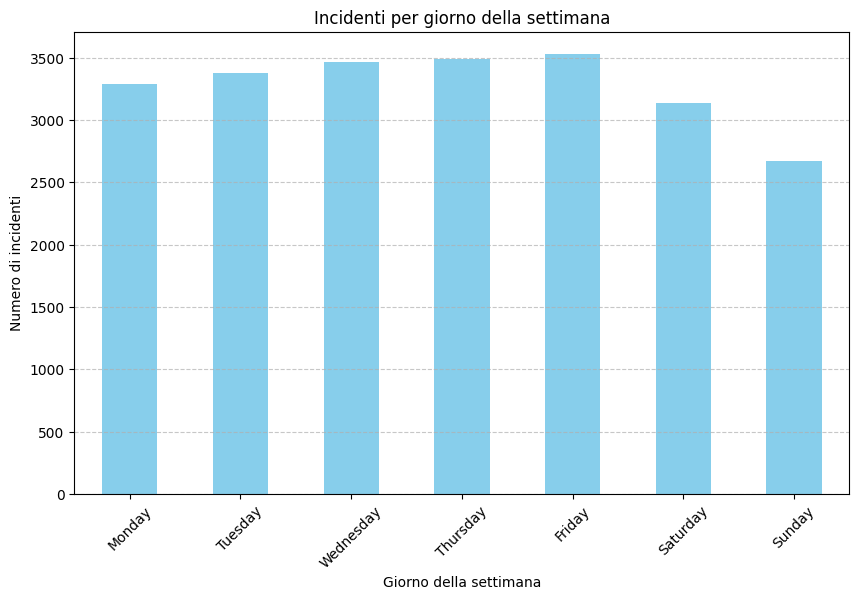

Venerdì, Giovedì e Mercoledì sono i giorni con il numero più significativo di incidenti (3530, 3490 e 3469 incidenti rispettivamente).


In [138]:
# 1. Conteggio incidenti per data per eliminare le date associate erroneamente
date_counts = df['date_clean'].value_counts().reset_index()
date_counts.columns = ['date_clean', 'num_accidents']

# 2. Creazione della soglia per eliminare le date associate erroneamente
threshold = 20
sospette = date_counts[date_counts['num_accidents'] > threshold]['date_clean']

# 3. Trasformiamo le date sospette in NaT
df.loc[df['date_clean'].isin(sospette), 'date_clean'] = pd.NaT

# 4. Creiamo la colonna weekday (0 = Lunedì, 6 = Domenica)
df['weekday'] = df['date_clean'].dt.day_name()

# 5. Conteggio incidenti per giorno della settimana
by_weekday = df['weekday'].value_counts()
print(by_weekday)


# 6. Conteggio incidenti per giorno della settimana (ignora NaT)
by_weekday = df['weekday'].value_counts().reindex([ 'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])


# 7. Grafico a barre
plt.figure(figsize=(10,6))
by_weekday.plot(kind='bar', color='skyblue')
plt.title("Incidenti per giorno della settimana")
plt.xlabel("Giorno della settimana")
plt.ylabel("Numero di incidenti")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha = 0.7)
plt.show()


# 8. Dizionario per la traduzione dei giorni della settimana
weekday_it = {
    'Monday': 'Lunedì',
    'Tuesday': 'Martedì',
    'Wednesday': 'Mercoledì',
    'Thursday': 'Giovedì',
    'Friday': 'Venerdì',
    'Saturday': 'Sabato',
    'Sunday': 'Domenica'
}

# 9. Conteggio incidenti per giorno della settimana
by_weekday = df['weekday'].value_counts()

# 10. Prendere i primi tre giorni
top_days = by_weekday.head(3)
wd1 = weekday_it[top_days.index[0]]
wd2 = weekday_it[top_days.index[1]]
wd3 = weekday_it[top_days.index[2]]
inc1 = top_days.iloc[0]
inc2 = top_days.iloc[1]
inc3 = top_days.iloc[2]

# 11. Creare il messaggio in italiano
print(f"{wd1}, {wd2} e {wd3} sono i giorni con il numero più significativo di incidenti ({inc1}, {inc2} e {inc3} incidenti rispettivamente).")

###Analisi per operatore

In [139]:
# Troviamo gli operatori che hanno avuto almeno un incidente con fatalities > 0
operators_with_fatalities = df[df['fatalities'] > 0]['operator'].unique()

# Selezioniamo solo gli operatori che **non** hanno mai avuto morti
operators_no_fatalities = df[~df['operator'].isin(operators_with_fatalities)]

# Raggruppamento per operatore e conteggio incidenti
operator_counts = df.groupby('operator').size().reset_index(name='Accidents')

# Ordinamento decrescente
operator_counts = operator_counts.sort_values(by='Accidents', ascending=False)

# Visualizzazione
print("Conteggio incidenti per operatore (prime 20 righe):")
print(operator_counts.head(20).to_string(index=False))

# Statistiche
print("\nStatistiche sugli incidenti per operatore:")
print(operator_counts['Accidents'].describe())

Conteggio incidenti per operatore (prime 20 righe):
         operator  Accidents
            USAAF       2604
             USAF       1120
              RAF        920
          US Navy        745
        German AF        517
          private        299
         Aeroflot        198
          Unknown        185
        Soviet AF        142
       Air France        138
             RAAF        130
American Airlines        116
        French AF        113
  Indian Airlines        109
       Spanish AF        108
Eastern Air Lines        105
              TWA        105
             RCAF        104
     Brazilian AF        103
  United Airlines        100

Statistiche sugli incidenti per operatore:
count    6017.000000
mean        3.982549
std        41.176299
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2604.000000
Name: Accidents, dtype: float64


#### Abbiamo scelto una soglia di significatività del numero di voli pari a 5 basandoci sulla media e la mediana della distribuzione


In [140]:

# Identifichiamo gli operatori che hanno avuto almeno un incidente con morti
operators_with_fatalities = df[df['fatalities'] > 0]['operator'].unique()

# Selezioniamo gli operatori che **non hanno mai avuto morti**
operators_no_fatalities = df[~df['operator'].isin(operators_with_fatalities)]

# Contiamo gli incidenti per ogni operatore
operator_incidents = operators_no_fatalities.groupby('operator').size().reset_index(name='Accidents')

# Applicazione della soglia minima di 5 incidenti
threshold = 5
operator_significant = operator_incidents[operator_incidents['Accidents'] >= threshold]

# Ordinamento decrescente per numero di incidenti
operator_significant = operator_significant.sort_values(by='Accidents', ascending=False)

# Prendiamo i top 5 operatori
top5_operators = operator_significant.head(5)
print("Di seguito i 5 operatori più sicuri con un numero significativo di incidenti (mai morti registrati e almeno 5 incidenti):")
print(top5_operators.to_string(index=False))

Di seguito i 5 operatori più sicuri con un numero significativo di incidenti (mai morti registrati e almeno 5 incidenti):
               operator  Accidents
                Ryanair         13
Trans Maldivian Airways         12
        Buffalo Airways         11
                  HISMA         10
     Universal Airlines          9


###Analisi per veivolo

In [141]:
# Raggruppamento per tipo di velivolo e somma delle fatalities
type_fatalities = df.groupby('type')['fatalities'].sum().reset_index()

# Ordinamento decrescente per numero di morti
type_fatalities = type_fatalities.sort_values(by='fatalities', ascending=False)

# Mostriamo i primi 10 tipi di velivolo più “pericolosi”
print("I 10 tipi di velivolo con più morti registrati:")
print(type_fatalities.head(10).to_string(index=False))

I 10 tipi di velivolo con più morti registrati:
                    type  fatalities
    Douglas C-47A (DC-3)        5780
     Douglas C-47 (DC-3)        2676
    Douglas C-47B (DC-3)        2017
        Boeing 767-223ER        1692
         Tupolev Tu-154M        1600
                 DC-9-32        1441
         Ilyushin Il-18V        1356
Lockheed C-130H Hercules        1271
           Antonov An-26        1246
        Junkers Ju-52/3m        1114


###Analisi temporale

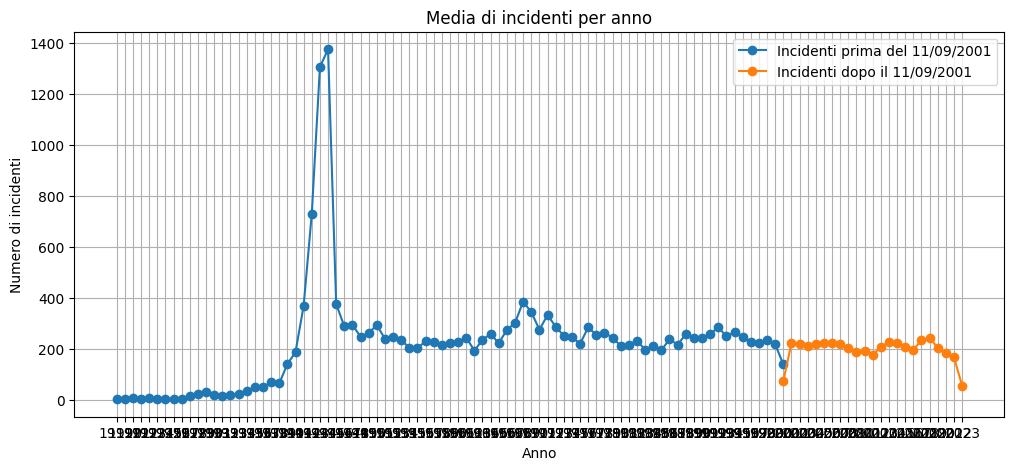

La media del numero di incidenti per anno prima del 11/09/2001 è 222.35 e dopo il 11/09/2001 è 195.74.


In [142]:
# Cutoff date
cutoff_date = pd.to_datetime("2001-09-11")

# Dividiamo il dataset
df_before = df[df['date_clean'] <= cutoff_date]
df_after = df[df['date_clean'] > cutoff_date]

# Funzione per calcolare media incidenti e morti per anno
def compute_yearly_stats(df_subset):
    stats = df_subset.groupby('year').agg({
        'operator': 'count',    # numero incidenti
        'fatalities': 'mean'    # media morti
    }).reset_index()
    stats.rename(columns={'operator': 'Incidents', 'fatalities': 'Avg_Fatalities'}, inplace=True)
    return stats

# Calcoliamo le statistiche
stats_before = compute_yearly_stats(df_before)
stats_after = compute_yearly_stats(df_after)

# ------------------------
# Line chart per incidenti
plt.figure(figsize=(12,5))
plt.plot(stats_before['year'], stats_before['Incidents'], label='Incidenti prima del 11/09/2001', marker='o')
plt.plot(stats_after['year'], stats_after['Incidents'], label='Incidenti dopo il 11/09/2001', marker='o')
plt.title('Media di incidenti per anno')
plt.xlabel('Anno')
plt.ylabel('Numero di incidenti')
plt.legend()
plt.grid(True)
plt.show()

# Calcolo della media del numero di incidenti per anno
avg_incidents_before = stats_before['Incidents'].mean()
avg_incidents_after = stats_after['Incidents'].mean()

# Commento
print(f"La media del numero di incidenti per anno prima del 11/09/2001 è {avg_incidents_before:.2f} e dopo il 11/09/2001 è {avg_incidents_after:.2f}.")





Dal grafico emerge che a seguito del 11/09/2001 il numero medio di incidenti per anno si sia assestato sui 200 all'anno mostrando un leggero calo rispetto al periodo ante 11/09/2001

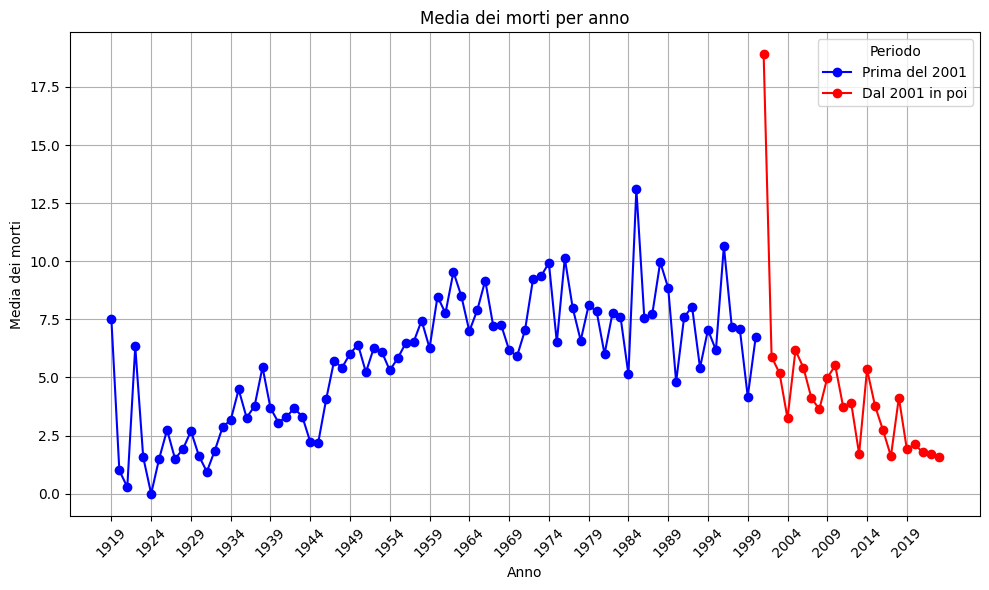

La media dei morti prima del 11/09/2001 è 6.06 e dopo il 11/09/2001 è 4.48.


In [143]:
# Cutoff date
cutoff_date = pd.to_datetime("2001-09-11")
cutoff_year = cutoff_date.year

# Creiamo una colonna che indica se la data è prima o dopo il cutoff
df['period'] = df['date_clean'].apply(lambda x: 'Before 11/09/2001' if x < cutoff_date else 'After 11/09/2001')

# Raggruppiamo per anno e periodo (non serve più per il grafico)
stats = df.groupby([df['date_clean'].dt.year, 'period']).agg(
    Incidents=('operator', 'count'),
    Avg_Fatalities=('fatalities', 'mean')
).reset_index().rename(columns={'date_clean': 'year'})

# Estrazione dell'anno 2001
df['year'] = df['date_clean'].dt.year

# Calcolo della media dei morti per anno
avg_fatalities_per_year = df.groupby('year')['fatalities'].mean().reset_index()

# Suddivisione dei dati in pre e post cutoff
pre_cutoff = avg_fatalities_per_year[avg_fatalities_per_year['year'] < cutoff_year]
post_cutoff = avg_fatalities_per_year[avg_fatalities_per_year['year'] >= cutoff_year]

# Grafico
plt.figure(figsize=(10,6))

plt.plot(pre_cutoff['year'], pre_cutoff['fatalities'], marker='o', color='blue', label='Prima del 2001')

plt.plot(post_cutoff['year'], post_cutoff['fatalities'], marker='o', color='red', label='Dal 2001 in poi')

plt.title('Media dei morti per anno')
plt.xlabel('Anno')
plt.ylabel('Media dei morti')
plt.grid(True)

start_year = int(avg_fatalities_per_year['year'].min())
end_year = int(avg_fatalities_per_year['year'].max())
plt.xticks(range(start_year, end_year+1, 5), rotation=45)

plt.legend(title='Periodo')
plt.tight_layout()
plt.show()

# Media dei morti per periodo
avg_fatalities_before = df[df['date_clean'] < cutoff_date]['fatalities'].mean()
avg_fatalities_after = df[df['date_clean'] >= cutoff_date]['fatalities'].mean()

print(f"La media dei morti prima del 11/09/2001 è {avg_fatalities_before:.2f} e dopo il 11/09/2001 è {avg_fatalities_after:.2f}.")

La media dei morti all'anno post 11/09/2001 è diminuita di 1.5 e nel corso degli anni a seguire è in calo.